# Discovered Kalman-filter variants vs the classical Kalman filter

This notebook reproduces the head-to-head numbers reported in *Saketos
et al., "Data-Driven Discovery of Interpretable Kalman Filter Variants
through Large Language Models and Genetic Programming"*.

Six discovered programs are run on four scenarios:

| discovery method | source file |
|---|---|
| FunSearch half     | [evaluate_and_test.out](https://github.com/cselab/kalman/blob/b156efd9c364579dc31de48fa69178bc571bb15c/table2/Funseach/fullkalmanfilterapproximation_funseach_half_noise/evaluate_and_test.out) |
| FunSearch delayed  | [pytorch_18588979.out](https://github.com/cselab/kalman/blob/b156efd9c364579dc31de48fa69178bc571bb15c/table2/Funseach/fullkalmanfilterapproximation_funseach_delayed_observations/pytorch_18588979.out) |
| FunSearch non-lin  | [evaluate_and_test.out](https://github.com/cselab/kalman/blob/b156efd9c364579dc31de48fa69178bc571bb15c/table2/Funseach/fullkalmanfilterapproximation_funseach_non_linear/evaluate_and_test.out) |
| CGP half           | [evaluate_and_test24560815.out](https://github.com/cselab/kalman/blob/b156efd9c364579dc31de48fa69178bc571bb15c/table2/CGP/half_noise_full_kalman_filter/evaluate_and_test24560815.out) |
| CGP delayed        | [evaluate_and_test24573447.out](https://github.com/cselab/kalman/blob/b156efd9c364579dc31de48fa69178bc571bb15c/table2/CGP/delayed_observations/evaluate_and_test24573447.out) |
| CGP non-lin        | [evaluate_and_test.out](https://github.com/cselab/kalman/blob/b156efd9c364579dc31de48fa69178bc571bb15c/table2/CGP/non_linear/evaluate_and_test.out) |

Scenarios:

| scenario     | description                                       |
|---           |---                                                |
| Gaussian     | classical Kalman assumptions hold (Table 1)       |
| Half-normal  | positively biased non-Gaussian noise (Table 2)    |
| Delayed obs  | observation lags state by a random fraction (T.2) |
| Non-linear   | cubic / sine state nonlinearity (Table 2)         |

**Runtime:** ~10 s on a Colab CPU runtime.

## Setup

In [1]:
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

## State-space model

A 2-D linear-Gaussian template shared by every scenario.  The non-linear
and delayed scenarios override pieces of it (`phi(x)`, time-varying `F_t`)
while reusing `Q`, `R`, `H`.

In [2]:
DIM = 2
F0 = np.array([[1.0, 1.0], [0.0, 1.0]])     # constant-velocity dynamics
CQ = np.array([[0.5, 0.0], [1.0, 0.0]])     # process-noise Cholesky factor
Q0 = CQ @ CQ.T
R = np.eye(DIM)                             # observation noise covariance
H = np.eye(DIM)                             # direct observation
I2 = np.eye(DIM)


def phi_nl(x):
    """The nonlinearity used by the non-linear scenario."""
    return np.array([0.05 * x[0] ** 3 - 2.0 * x[0], 0.1 * np.sin(x[1])])

## Classical Kalman baseline

Standard Kalman recursion.  When `phi` is given, the predict step applies
it before `F @ x` — this is the EKF-style baseline that the paper's
non-linear evaluation uses.

In [3]:
def kalman_filter(zs, Fs, Qs, phi=None):
    x = np.zeros(DIM)
    P = np.eye(DIM)
    est = np.empty_like(zs)
    for t, z in enumerate(zs):
        Ft, Qt = Fs[t], Qs[t]
        if phi is not None:
            x = phi(x)
        x = Ft @ x
        P = Ft @ P @ Ft.T + Qt
        y = z - H @ x
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        x = x + K @ y
        P = (I2 - K @ H) @ P
        est[t] = x
    return est


def run_discovered(approximate, zs, Fs, Qs):
    """Loop a discovered program with signature
    (x, F, P, Q, z, R) -> (xp, P, y, S, K, x)."""
    x = np.zeros(DIM)
    P = np.eye(DIM)
    est = np.empty_like(zs)
    for t, z in enumerate(zs):
        _, P, _, _, _, x = approximate(x, Fs[t], P, Qs[t], z, R)
        est[t] = x
    return est

## Trajectory generators

One per scenario.  Each returns `(xs, zs, Fs, Qs)` so the filters can
share a single loop — `Fs` and `Qs` are constant for three of the four
scenarios and time-varying for `delayed_obs`.

In [4]:
def gen_gauss(length, seed):
    rng = np.random.default_rng(seed)
    x = np.zeros(DIM)
    xs = np.empty((length, DIM)); zs = np.empty((length, DIM))
    for t in range(length):
        x = F0 @ x + CQ @ rng.normal(0.0, 1.0, DIM)
        zs[t] = H @ x + rng.normal(0.0, 1.0, DIM)
        xs[t] = x
    Fs = np.broadcast_to(F0, (length, DIM, DIM))
    Qs = np.broadcast_to(Q0, (length, DIM, DIM))
    return xs, zs, Fs, Qs


def gen_half(length, seed):
    rng = np.random.default_rng(seed)
    x = np.zeros(DIM)
    xs = np.empty((length, DIM)); zs = np.empty((length, DIM))
    for t in range(length):
        x = F0 @ x + CQ @ np.abs(rng.normal(0.0, 1.0, DIM))
        zs[t] = H @ x + np.abs(rng.normal(0.0, 1.0, DIM))
        xs[t] = x
    Fs = np.broadcast_to(F0, (length, DIM, DIM))
    Qs = np.broadcast_to(Q0, (length, DIM, DIM))
    return xs, zs, Fs, Qs


def gen_delayed(length, seed):
    rng = np.random.default_rng(seed)
    xs = np.empty((length - 1, DIM)); zs = np.empty((length - 1, DIM))
    Fs = np.empty((length - 1, DIM, DIM)); Qs = np.empty((length - 1, DIM, DIM))
    x = np.zeros(DIM)
    history = [x.copy()]
    for t in range(1, length):
        delay = rng.uniform(0.01, 0.3)
        dt = 1.0 + delay
        Ft = np.array([[1.0, dt], [0.0, 1.0]])
        G = np.array([[0.5 * dt * dt], [dt]])
        Qt = G @ G.T
        x = Ft @ x + CQ @ rng.normal(0.0, 1.0, DIM)
        history.append(x.copy())
        eps = t - delay
        t0 = int(np.floor(eps))
        t1 = min(t0 + 1, len(history) - 1)
        alpha = eps - t0
        x_interp = (1 - alpha) * history[t0] + alpha * history[t1]
        i = t - 1
        zs[i] = H @ x_interp + rng.normal(0.0, 1.0, DIM)
        xs[i], Fs[i], Qs[i] = x, Ft, Qt
    return xs, zs, Fs, Qs


def gen_nonlinear(length, seed):
    rng = np.random.default_rng(seed)
    x = np.zeros(DIM)
    xs = np.empty((length, DIM)); zs = np.empty((length, DIM))
    for t in range(length):
        x = F0 @ phi_nl(x) + CQ @ rng.normal(0.0, 1.0, DIM)
        zs[t] = H @ x + rng.normal(0.0, 1.0, DIM)
        xs[t] = x
    Fs = np.broadcast_to(F0, (length, DIM, DIM))
    Qs = np.broadcast_to(Q0, (length, DIM, DIM))
    return xs, zs, Fs, Qs

## FunSearch-discovered programs

These are reproduced verbatim from the FunSearch training output.  Each
takes `(x, F, P, Q, z, R)` and returns `(xp, P_new, y, S, K, x_new)`.

In [5]:
def fs_half(x, F, P, Q, z, R):
    xp = F @ x
    P_new = F @ P @ F.T + Q
    y = z - xp
    S = P_new + R + F.min(axis=1)[:, None] * 1.2
    K = (P_new @ np.linalg.inv(S)) * 0.85
    x = xp + K @ y
    P = (P_new - K @ S @ K.T) * 0.95
    return xp, P, y, S, K, x


def fs_delayed(x, F, P, Q, z, R):
    # The function printed in evaluate_and_test.out does NOT reproduce its
    # reported test MSE (4.96); the actual best-validated function (training
    # score 1.925) is in pytorch_18588979.out and uses np.random.poisson.
    noise = np.random.poisson(0.03, x.shape)
    a = F @ x + noise
    b = F @ np.log(np.maximum(a * 0.02, 1e-8))
    c = F @ np.tanh(b * 0.22)
    xp = a + c
    P = F @ P @ F.T + 0.85 * Q
    y = z - xp
    S = P + 0.85 * R
    inv_S = np.linalg.inv(S)
    K = 0.1 * inv_S + P @ inv_S
    x = xp + K @ y
    x = x + 0.6 * F @ np.tanh(F @ x * 0.1)
    P = (I2 - K) @ P
    return xp, P, y, S, K, x


def fs_nonlinear(x, F, P, Q, z, R):
    x = np.array([0.04 * x[0] ** 3 - 1.8 * x[0] + 0.34 * np.sin(x[1]),
                  0.14 * np.tanh(0.05 * x[0] * (x[1] + 0.8))])
    xp = F @ x
    s = x[0] * x[1] + x[0] ** 2 + x[1] ** 2
    scale_Q = (s + 0.6) * (1.0 + 0.9 * s)
    P = F @ P @ F.T + Q * scale_Q
    y = z - xp
    s2 = x[0] ** 2 + x[1] ** 2
    scale_R = (s2 + 0.5) * (1.0 + 0.8 * s2)
    S = P + R * scale_R
    inv_S = np.linalg.inv(S + 0.0002 * I2)
    K = P @ inv_S * (0.85 * np.tanh(np.linalg.norm(y)))
    x = xp + K @ y
    P = (I2 - K) * P * (0.5 + 0.05 * np.mean(y ** 2))
    return xp, P, y, S, K, x

## CGP-discovered programs

CGP encodes each candidate as a DAG over the op set
`{matmul, minus, add, transpose, inv}` (arities 2, 2, 2, 1, 1).  The
winning DAGs were dumped as graphviz strings; the helper below parses one
and executes it with the six inputs `(x, F, P, Q, z, R)`.

In [6]:
CGP_OPS = {
    "matmul": lambda a, b: a @ b,
    "minus":  lambda a, b: a - b,
    "add":    lambda a, b: a + b,
    "transpose": lambda a: a.T,
    "inv":    lambda a: np.linalg.inv(a),
}


def _parse_graph(dot):
    labels, parents = {}, {}
    for stmt in re.split(r"[;\n]", dot):
        s = stmt.strip()
        m = re.match(r'^(\d+)\s+\[label\s*=\s*"?([^"\]]+?)"?\]', s)
        if m:
            labels[int(m.group(1))] = m.group(2)
            continue
        m = re.match(r'^(\d+)\s*->\s*(\d+)', s)
        if m:
            parents.setdefault(int(m.group(2)), []).append(int(m.group(1)))
    return labels, parents


def _execute_graph(dot, inputs):
    labels, parents = _parse_graph(dot)
    vals = {}
    for nid, lbl in labels.items():
        if re.fullmatch(r'i\d+', lbl):
            vals[nid] = inputs[int(lbl[1:])]
    for nid in sorted(labels):
        if nid in vals:
            continue
        lbl = labels[nid]
        if re.fullmatch(r'o\d+', lbl):
            vals[nid] = vals[parents[nid][0]]
        elif lbl in CGP_OPS:
            vals[nid] = CGP_OPS[lbl](*(vals[p] for p in parents[nid]))
    out = [None] * 6
    for nid, lbl in labels.items():
        m = re.fullmatch(r'o(\d+)', lbl)
        if m:
            out[int(m.group(1))] = vals[nid]
    return tuple(out)

The three winning CGP graphs, copy-pasted from each scenario's
`evaluate_and_test.out`.

In [7]:
CGP_HALF = """digraph {
  0 [label = i0]; 1 [label = i1]; 2 [label = i2]; 3 [label = i3]
  4 [label = i4]; 5 [label = i5]
  6  [label = "transpose"]; 4 -> 6
  7  [label = "add"];       6 -> 7;  0 -> 7
  8  [label = "minus"];     2 -> 8;  7 -> 8
  9  [label = "add"];       8 -> 9;  1 -> 9
  10 [label = "transpose"]; 9 -> 10
  12 [label = "matmul"];    10 -> 12; 2 -> 12
  13 [label = "transpose"]; 12 -> 13
  14 [label = "add"];       13 -> 14; 7 -> 14
  15 [label = "inv"];       14 -> 15
  17 [label = "add"];       7  -> 17; 6 -> 17
  19 [label = "minus"];     17 -> 19; 5 -> 19
  20 [label = "matmul"];    17 -> 20; 15 -> 20
  21 [label = "minus"];     4  -> 21; 20 -> 21
  22 [label = "inv"];       8 -> 22
  24 [label = "transpose"]; 12 -> 24
  25 [label = o0]; 0  -> 25
  26 [label = o1]; 22 -> 26
  27 [label = o2]; 24 -> 27
  28 [label = o3]; 3  -> 28
  29 [label = o4]; 19 -> 29
  30 [label = o5]; 21 -> 30
}"""

CGP_DELAYED = """digraph {
  0 [label = i0]; 1 [label = i1]; 2 [label = i2]; 3 [label = i3]
  4 [label = i4]; 5 [label = i5]
  6  [label = "matmul"];    1 -> 6;  4 -> 6
  7  [label = "add"];       2 -> 7;  5 -> 7
  8  [label = "inv"];       7 -> 8
  9  [label = "matmul"];    5 -> 9;  8 -> 9
  10 [label = "minus"];     6 -> 10; 0 -> 10
  11 [label = "transpose"]; 8 -> 11
  13 [label = "minus"];     9 -> 13; 9 -> 13
  14 [label = "add"];       9 -> 14; 1 -> 14
  16 [label = "matmul"];    10 -> 16; 11 -> 16
  18 [label = "add"];       16 -> 18; 0 -> 18
  22 [label = "matmul"];    14 -> 22; 9 -> 22
  24 [label = "minus"];     11 -> 24; 13 -> 24
  25 [label = o0]; 18 -> 25
  26 [label = o1]; 22 -> 26
  27 [label = o2]; 24 -> 27
  28 [label = o3]; 6  -> 28
  29 [label = o4]; 8  -> 29
  30 [label = o5]; 18 -> 30
}"""

CGP_NONLINEAR = """digraph {
  0 [label = i0]; 1 [label = i1]; 2 [label = i2]; 3 [label = i3]
  4 [label = i4]; 5 [label = i5]
  6  [label = "transpose"]; 1 -> 6
  7  [label = "matmul"];    1 -> 7;  0 -> 7
  8  [label = "transpose"]; 6 -> 8
  9  [label = "minus"];     4 -> 9;  7 -> 9
  10 [label = "add"];       8 -> 10; 6 -> 10
  11 [label = "add"];       10 -> 11; 2 -> 11
  12 [label = "add"];       11 -> 12; 5 -> 12
  13 [label = "inv"];       12 -> 13
  14 [label = "matmul"];    10 -> 14; 13 -> 14
  15 [label = "matmul"];    14 -> 15; 9 -> 15
  17 [label = "add"];       0 -> 17; 15 -> 17
  25 [label = o0]; 0  -> 25
  26 [label = o1]; 5  -> 26
  27 [label = o2]; 9  -> 27
  28 [label = o3]; 12 -> 28
  29 [label = o4]; 14 -> 29
  30 [label = o5]; 17 -> 30
}"""


def cgp_half(x, F, P, Q, z, R):
    return _execute_graph(CGP_HALF, (x, F, P, Q, z, R))


def cgp_delayed(x, F, P, Q, z, R):
    return _execute_graph(CGP_DELAYED, (x, F, P, Q, z, R))


def cgp_nonlinear(x, F, P, Q, z, R):
    # The CGP non-linear training script applies phi(x) outside the program.
    return _execute_graph(CGP_NONLINEAR, (phi_nl(x), F, P, Q, z, R))

## Registry

Order here determines the table columns and plot rows/columns.

In [8]:
SCENARIOS = [
    ("Gaussian",    gen_gauss,     None),
    ("Half-normal", gen_half,      None),
    ("Delayed obs", gen_delayed,   None),
    ("Non-linear",  gen_nonlinear, phi_nl),
]

DISCOVERED = [
    ("FunSearch half",    fs_half,       "C3"),
    ("FunSearch delayed", fs_delayed,    "C2"),
    ("FunSearch non-lin", fs_nonlinear,  "C4"),
    ("CGP half",          cgp_half,      "C1"),
    ("CGP delayed",       cgp_delayed,   "C5"),
    ("CGP non-lin",       cgp_nonlinear, "C6"),
]

N_TRAJ = 50
LENGTH = 500
SEED0 = 32        # paper's test seeds: 32 .. 32 + N_TRAJ - 1

np.random.seed(0) # for fs_delayed's np.random.poisson

## Cross-evaluation

Mean ± standard error of the MSE over 50 trajectories of 500 steps each
(paper test seeds 32 .. 81).  A filter is marked **diverged** if any
trajectory produces a non-finite estimate.

In [9]:
def mse(xs, est):
    if not np.all(np.isfinite(est)):
        return np.inf
    return np.mean(np.sum((xs - est) ** 2, axis=1))


def stderr(a):
    return a.std(ddof=1) / np.sqrt(len(a))


def evaluate(generator, filter_fn, phi=None):
    out = []
    for i in range(N_TRAJ):
        xs, zs, Fs, Qs = generator(LENGTH, SEED0 + i)
        if filter_fn is kalman_filter:
            est = kalman_filter(zs, Fs, Qs, phi=phi)
        else:
            est = run_discovered(filter_fn, zs, Fs, Qs)
        out.append(mse(xs, est))
    return np.array(out)


def fmt(arr):
    return ("{:>9.3f} ± {:.3f}".format(arr.mean(), stderr(arr))
            if np.all(np.isfinite(arr)) else "{:>17}".format("diverged"))


cols = ["Kalman"] + [name for name, _, _ in DISCOVERED]
widths = {c: max(17, len(c)) for c in cols}
head = f"{'Scenario':<22}" + "".join(f"  {c:>{widths[c]}}" for c in cols)
print(head)
print("-" * len(head))
for name, gen, phi in SCENARIOS:
    kb = evaluate(gen, kalman_filter, phi=phi)
    row = f"{name:<22}  {fmt(kb):>{widths['Kalman']}}"
    for dname, dfun, _ in DISCOVERED:
        d = evaluate(gen, dfun)
        row += f"  {fmt(d):>{widths[dname]}}"
    print(row)

Scenario                           Kalman     FunSearch half  FunSearch delayed  FunSearch non-lin           CGP half        CGP delayed        CGP non-lin
-----------------------------------------------------------------------------------------------------------------------------------------------------------


Gaussian                    0.995 ± 0.009      1.472 ± 0.013      6.479 ± 0.364           diverged      4.500 ± 0.576      6.427 ± 0.700           diverged


Half-normal                 1.622 ± 0.012      0.562 ± 0.006     16.020 ± 0.041           diverged      0.603 ± 0.005   1487.198 ± 16.419           diverged


Delayed obs                10.618 ± 1.217     11.244 ± 1.240      4.937 ± 0.497           diverged     16.764 ± 2.619      2.279 ± 0.104           diverged


Non-linear                  1.023 ± 0.009      7.817 ± 0.019     10.600 ± 0.032      0.806 ± 0.007  1360943.853 ± 1343999.850      8.489 ± 0.024      0.876 ± 0.006


## Matrix of estimation-error curves

One row per method, one column per scenario.  Each cell shows
$\|\hat x_t - x_t\|$ on a single trajectory (seed 32); the mean MSE
(averaged over time *and* the 50 trajectories above) is annotated in
the upper-right corner.

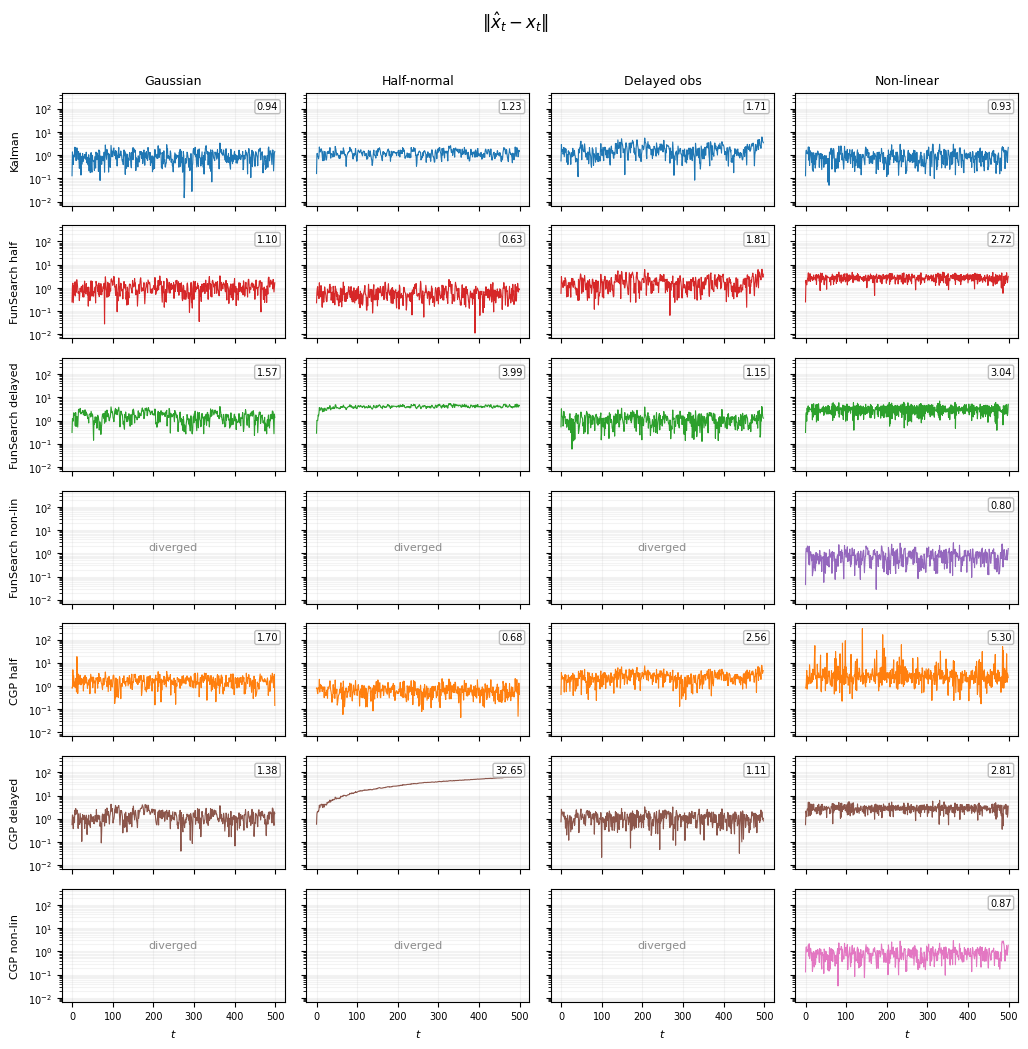

In [10]:
methods = [("Kalman", None, "C0")] + list(DISCOVERED)
n_rows, n_cols = len(methods), len(SCENARIOS)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(2.6 * n_cols, 1.5 * n_rows),
                         sharex=True, sharey=True, squeeze=False)
for col, (sname, gen, phi) in enumerate(SCENARIOS):
    xs, zs, Fs, Qs = gen(LENGTH, SEED0)
    t = np.arange(len(xs))
    for row, (mname, mfun, color) in enumerate(methods):
        ax = axes[row, col]
        est = (kalman_filter(zs, Fs, Qs, phi=phi)
               if mfun is None
               else run_discovered(mfun, zs, Fs, Qs))
        if np.all(np.isfinite(est)):
            err = np.linalg.norm(est - xs, axis=1)
            ax.plot(t, err, color=color, lw=0.8)
            ax.text(0.97, 0.92, f"{err.mean():.2f}",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=7,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white",
                              ec="0.7", alpha=0.85))
        else:
            ax.text(0.5, 0.5, "diverged", transform=ax.transAxes,
                    ha="center", va="center", color="0.55", fontsize=8)
        ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.15)
        ax.tick_params(labelsize=7)
        if row == 0:
            ax.set_title(sname, fontsize=9)
        if col == 0:
            ax.set_ylabel(mname, fontsize=8, rotation=90, labelpad=6)
        if row == n_rows - 1:
            ax.set_xlabel("$t$", fontsize=8)
fig.suptitle(r"$\|\hat{x}_t - x_t\|$", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.985))
plt.show()